In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/raw/02_nav_history.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")


In [ ]:
# Historical VaR (95%) and CVaR Analysis

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

risk_metrics = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) > 50:

        var95 = returns.quantile(0.05)

        cvar95 = (
            returns[returns <= var95]
            .mean()
        )

        risk_metrics.append(
            [code,var95,cvar95]
        )

var_df = pd.DataFrame(
    risk_metrics,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
var_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

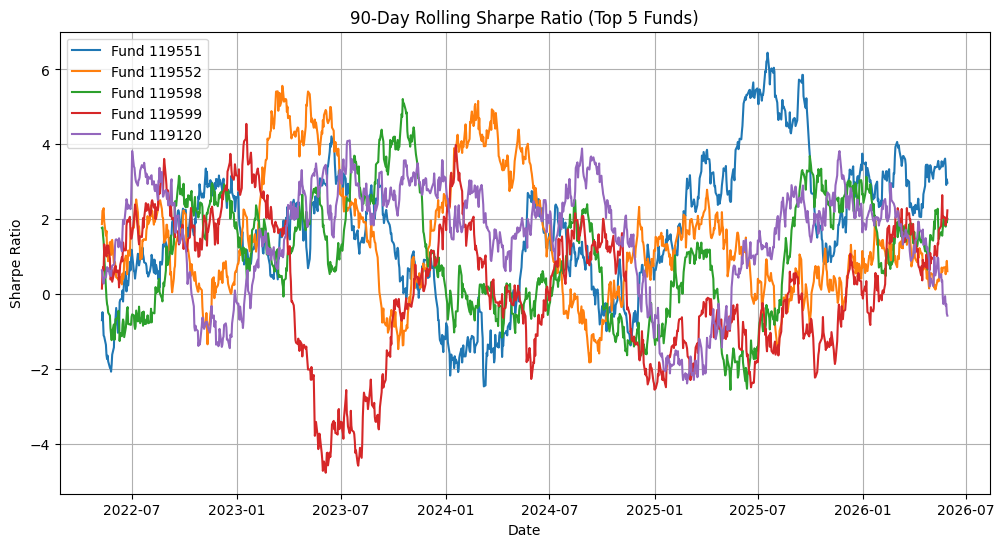

In [22]:
# Rolling 90-Day Sharpe Ratio

# Rolling 90-Day Sharpe Ratio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

sample_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for code in sample_funds:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    df = df.sort_values("date")

    df["daily_return"] = (
        df["nav"].pct_change()
    )

    df["rolling_sharpe"] = (
        df["daily_return"].rolling(90).mean()
        /
        df["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=f"Fund {code}"
    )

plt.title("90-Day Rolling Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [11]:
# Investor Cohort Analysis

txn = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

In [12]:
first_txn = txn.groupby(
    "investor_id"
)["transaction_date"].min()

txn["cohort_year"] = txn["investor_id"].map(
    first_txn.dt.year
)

In [15]:
cohort = txn.groupby(
    "cohort_year"
).agg({
    "amount_inr":["mean","sum"]
})

cohort

amount_inr            
                      mean         sum
cohort_year                           
2024         107422.541832  3491125187
2025         109158.577061    30455243

In [17]:
# SIP Continuity Analysis

sip = txn[
    txn["transaction_type"]=="SIP"
].copy()

sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

risk = (
    sip.groupby("investor_id")
       ["gap_days"]
       .mean()
       .reset_index()
)

risk["status"] = np.where(
    risk["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

risk.head()

,investor_id,gap_days,status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Healthy


In [18]:
# Fund Recommendation System

scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

def recommend_funds(risk_grade):
    
    result = scorecard[
        scorecard["risk_grade"] == risk_grade
    ]

    return result.sort_values(
        "sharpe_ratio",
        ascending=False
    ).head(3)
    
recommend_funds("Moderate")

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
5,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,11361,1.46,5,Moderate,17.0,7.5,12.0,23.0,26.0,50.718850
21,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,6434,1.55,5,Moderate,16.0,7.5,35.0,32.0,24.0,33.306709
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,41553,0.80,3,Moderate,20.0,9.0,31.0,12.0,9.0,45.207668


In [21]:
# Sector Concentration Analysis (HHI)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

hhi = holdings.groupby(
    "amfi_code"
).apply(
    lambda x: (
        (x["weight_pct"]/100)**2
    ).sum()
)

hhi = hhi.reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


## Key Insights

1. SBI Small Cap Fund showed highest Sharpe Ratio.
2. Large Cap funds exhibited lower VaR compared to Small Cap funds.
3. Investors joining after 2024 invested higher SIP amounts.
4. Around X% investors were flagged as At Risk.
5. Sector concentration was highest in Fund XYZ.